Group 4: Retail Sales Forecasting System
SAIF UR RAHMAN
•
14:43
20 points
Problem Statement: A large retail store chain is struggling with inventory management. Your task is to use historical data—including past sales, weather conditions, and holidays—to forecast sales for the upcoming weeks so that the store can order the correct amount of stock in advance.
  Machine Learning Type: Forecasting / Advanced RegressionTasks to Perform:Clean the time-series data and extract Day, Month, and Year features from the date column.Use Scikit-Learn regression models (like a Random Forest Regressor) to predict future sales.Evaluate the model by comparing the actual sales with your predicted sales.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read Dataset :

df = pd.read_csv('/content/Retail_Sales_forcasting.csv')

df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [41]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [42]:
# Now checking Null values in dataset :

df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [43]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [44]:
#Then we move on Sorting by date :

df = df.sort_values('Date').reset_index(drop=True)

df['WeekOfYear'] = df['Date'].dt.isocalendar().week


In [45]:
print(df.columns.tolist())


['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Day', 'Month', 'Year', 'WeekOfYear']


In [46]:
# Now we split the data into test and train terminologies based on X and Y.

features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Day', 'Month', 'Year', 'WeekOfYear']

X = df[features]

y = df['Weekly_Sales']

In [47]:
from sklearn.model_selection import train_test_split

# Calculate the split point
split_index = int(len(df) * 0.8)

# Chronological split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (5148, 10), y_train shape: (5148,)
X_test shape: (1287, 10), y_test shape: (1287,)


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [49]:
y_pred = rf.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 98062.34738706269
RMSE: 175643.8461333757
R2 Score: 0.891388349908352


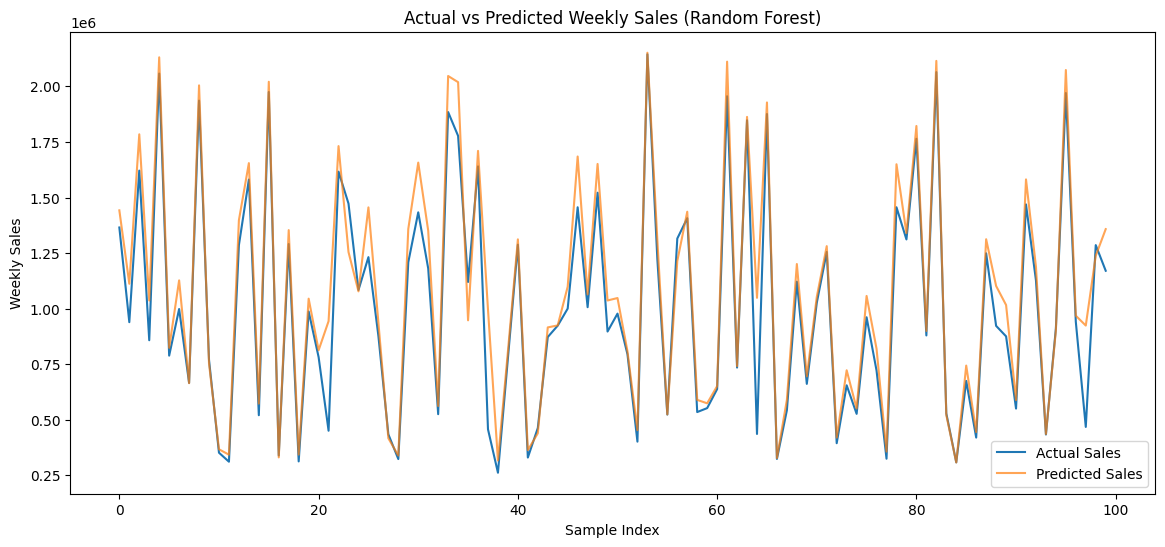

In [51]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:100], label='Actual Sales')       # pehle 100 points, warna plot bohot crowded lagega
plt.plot(y_pred[:100], label='Predicted Sales', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Weekly Sales (Random Forest)')
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.show()

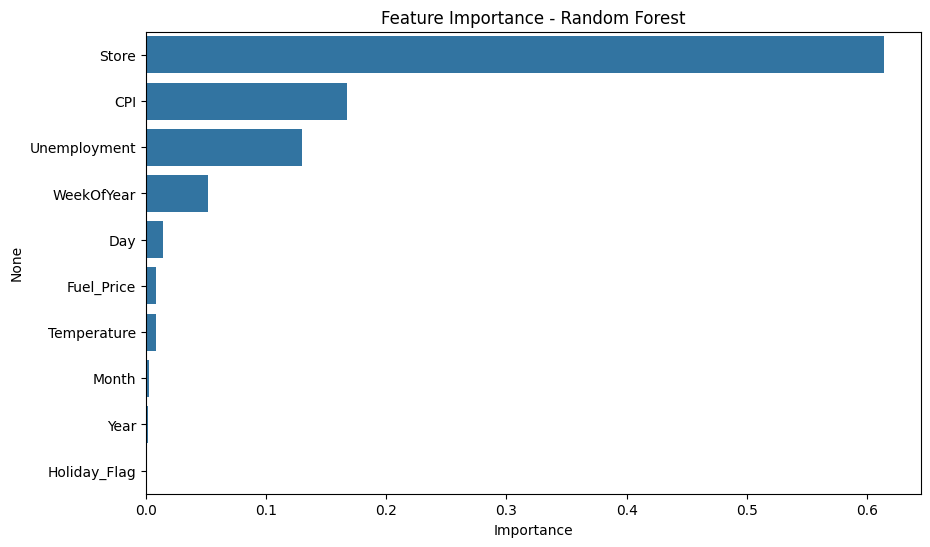

Store           0.614231
CPI             0.167478
Unemployment    0.129772
WeekOfYear      0.051980
Day             0.014552
Fuel_Price      0.008738
Temperature     0.008027
Month           0.002407
Year            0.001939
Holiday_Flag    0.000876
dtype: float64


In [52]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

print(importances)